### Feature-Based Clustering (K-Means, Hierarchical, DBSCAN)

Dataset shape: (50000, 11)


,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,Hashtags
0,132131,flong,Station activity person against natural majori...,85,1,2353,False,1,Adkinston,2020-05-11 15:29:50,NaN
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,True,0,Sanderston,2022-11-26 05:18:10,both live
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,True,0,Harrisonfurt,2022-08-08 03:16:54,phone ahead
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,True,1,Martinezberg,2021-08-14 22:27:05,ever quickly new I
4,704441,noah87,Animal sign six data good or.,26,3,8438,False,1,Camachoville,2020-04-13 21:24:21,foreign mention


Label column: None
Number of features used: 5
Explained variance (PCA): [0.20235413 0.20180743]
K-Means silhouette score: 0.16885140345377572
Hierarchical silhouette score: 0.14818792495227925
DBSCAN clusters detected: 2


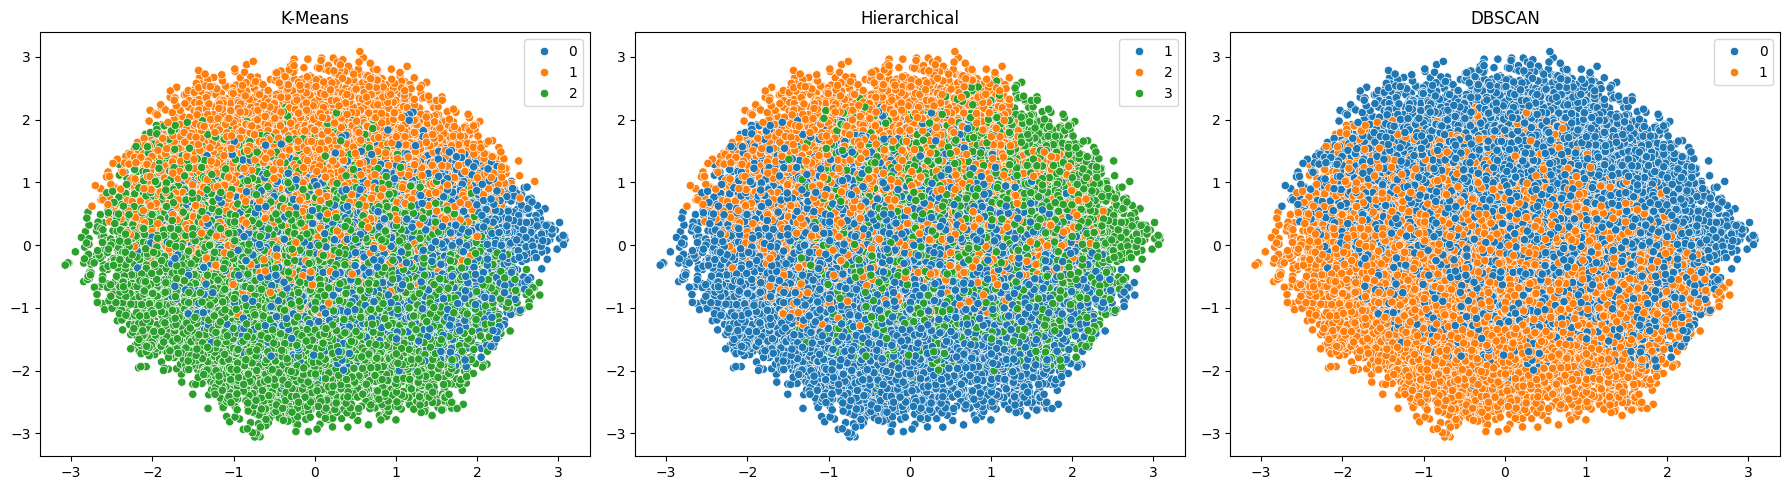

In [5]:
# =========================
# FEATURE-BASED CLUSTERING
# =========================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1. Load dataset
# -------------------------
csv_path = "Twitter-Bot-Detection-Dataset/bot_detection_data.csv"
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
display(df.head())

# -------------------------
# 2. Identify label column (if present)
# -------------------------
label_column = None
for col in df.columns:
    if col.lower() in ["label", "bot_label", "is_bot", "class"]:
        label_column = col
        break

print("Label column:", label_column)

# -------------------------
# 3. Select numerical features
# -------------------------
X = df.select_dtypes(include=[np.number]).copy()

if label_column and label_column in X.columns:
    X.drop(columns=[label_column], inplace=True)

X = X.fillna(0)

print("Number of features used:", X.shape[1])

# -------------------------
# 4. Scale features
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 5. PCA for visualization
# -------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance (PCA):", pca.explained_variance_ratio_)

# -------------------------
# 6. K-Means clustering
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means silhouette score:",
      silhouette_score(X_scaled, kmeans_labels))

# -------------------------
# 7. Hierarchical clustering
# -------------------------
Z = linkage(X_scaled, method="ward")
hier_labels = fcluster(Z, t=3, criterion="maxclust")

print("Hierarchical silhouette score:",
      silhouette_score(X_scaled, hier_labels))

# -------------------------
# 8. DBSCAN clustering
# -------------------------
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print("DBSCAN clusters detected:", n_clusters)

# -------------------------
# 9. Visualization
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=kmeans_labels, palette="tab10", ax=axes[0]
)
axes[0].set_title("K-Means")

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=hier_labels, palette="tab10", ax=axes[1]
)
axes[1].set_title("Hierarchical")

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=dbscan_labels, palette="tab10", ax=axes[2]
)
axes[2].set_title("DBSCAN")

plt.tight_layout()
plt.show()

# -------------------------
# 10. Optional: compare with labels
# -------------------------
if label_column:
    df["kmeans_cluster"] = kmeans_labels
    print(pd.crosstab(df[label_column], df["kmeans_cluster"]))


### FEATURE-BASED CLUSTERING: K-Means, Hierarchical, DBSCAN, HDBSCAN

Dataset shape: (50000, 11)


,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,Hashtags
0,132131,flong,Station activity person against natural majori...,85,1,2353,False,1,Adkinston,2020-05-11 15:29:50,NaN
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,True,0,Sanderston,2022-11-26 05:18:10,both live
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,True,0,Harrisonfurt,2022-08-08 03:16:54,phone ahead
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,True,1,Martinezberg,2021-08-14 22:27:05,ever quickly new I
4,704441,noah87,Animal sign six data good or.,26,3,8438,False,1,Camachoville,2020-04-13 21:24:21,foreign mention


Label column: None
Number of features used: 5
Explained variance (PCA): [0.20235413 0.20180743]
K-Means silhouette score: 0.16885140345377572
Hierarchical silhouette score: 0.14818792495227925
DBSCAN clusters detected: 2
HDBSCAN clusters detected: 12
HDBSCAN noise ratio: 0.0


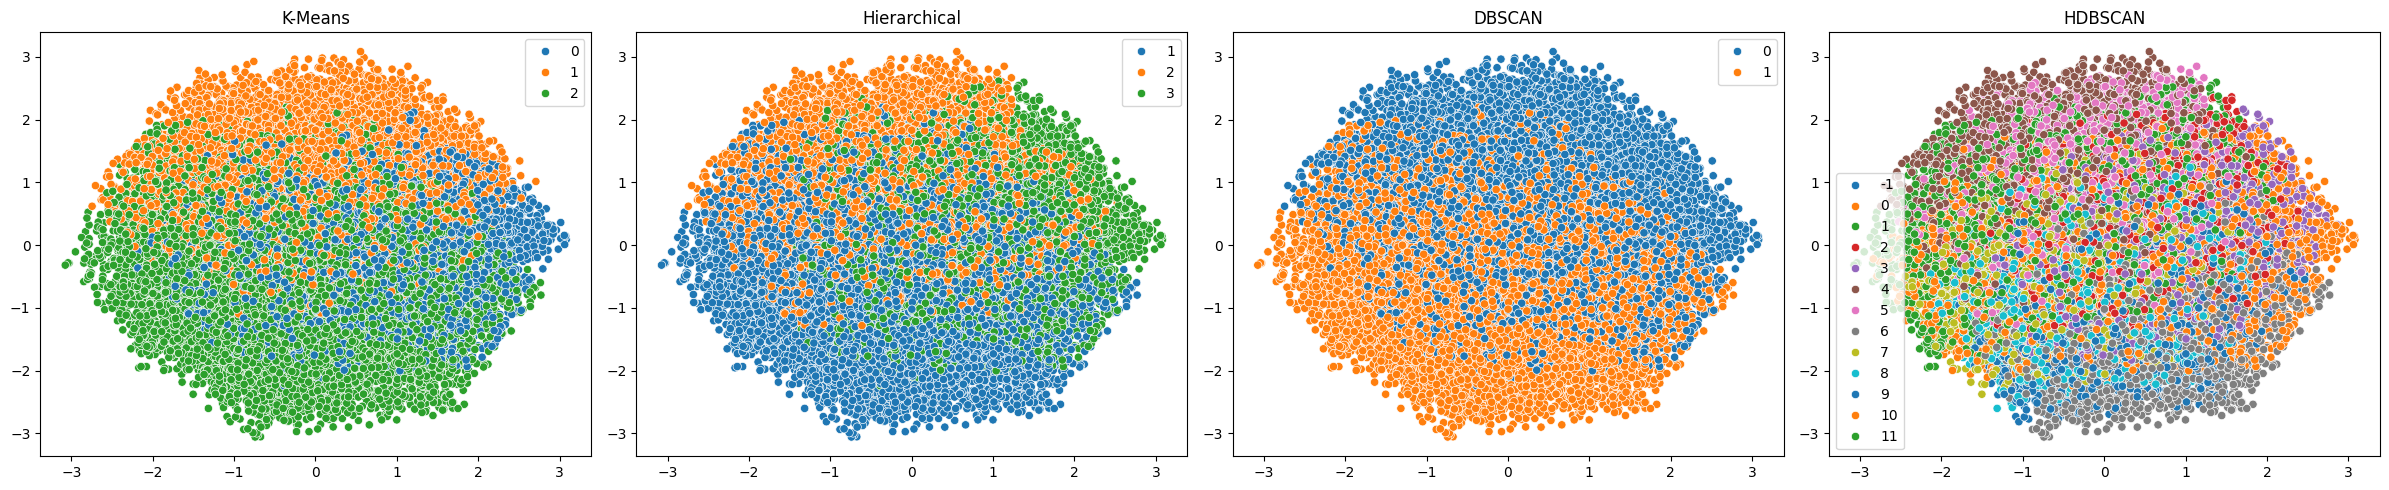

In [8]:
# =========================
# FEATURE-BASED CLUSTERING
# =========================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster

import hdbscan

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1. Load dataset
# -------------------------
csv_path = "Twitter-Bot-Detection-Dataset/bot_detection_data.csv"
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
display(df.head())

# -------------------------
# 2. Identify label column (if present)
# -------------------------
label_column = None
for col in df.columns:
    if col.lower() in ["label", "bot_label", "Bot Label", "is_bot", "class"]:
        label_column = col
        break

print("Label column:", label_column)

# -------------------------
# 3. Select numerical features
# -------------------------
X = df.select_dtypes(include=[np.number]).copy()

if label_column and label_column in X.columns:
    X.drop(columns=[label_column], inplace=True)

X = X.fillna(0)

print("Number of features used:", X.shape[1])

# -------------------------
# 4. Scale features
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 5. PCA for visualization
# -------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance (PCA):", pca.explained_variance_ratio_)

# -------------------------
# 6. K-Means clustering
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means silhouette score:",
      silhouette_score(X_scaled, kmeans_labels))

# -------------------------
# 7. Hierarchical clustering
# -------------------------
Z = linkage(X_scaled, method="ward")
hier_labels = fcluster(Z, t=3, criterion="maxclust")

print("Hierarchical silhouette score:",
      silhouette_score(X_scaled, hier_labels))

# -------------------------
# 8. DBSCAN clustering
# -------------------------
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print("DBSCAN clusters detected:", dbscan_clusters)

# -------------------------
# 9. HDBSCAN clustering (NEW)
# -------------------------
hdbscan_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric="euclidean"
)

hdbscan_labels = hdbscan_clusterer.fit_predict(X_scaled)

hdbscan_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
noise_ratio = np.mean(hdbscan_labels == -1)

print("HDBSCAN clusters detected:", hdbscan_clusters)
print("HDBSCAN noise ratio:", round(noise_ratio, 3))

# -------------------------
# 10. Visualization
# -------------------------
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=kmeans_labels, palette="tab10", ax=axes[0]
)
axes[0].set_title("K-Means")

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=hier_labels, palette="tab10", ax=axes[1]
)
axes[1].set_title("Hierarchical")

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=dbscan_labels, palette="tab10", ax=axes[2]
)
axes[2].set_title("DBSCAN")

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=hdbscan_labels, palette="tab10", ax=axes[3]
)
axes[3].set_title("HDBSCAN")

plt.tight_layout()
plt.show()

# -------------------------
# 11. Optional: compare with labels
# -------------------------
if label_column:
    df["hdbscan_cluster"] = hdbscan_labels
    print(pd.crosstab(df[label_column], df["hdbscan_cluster"]))

### FEATURE-BASED CLUSTERING: K-Means, Hierarchical, DBSCAN, HDBSCAN (synthetic dataset)

Dataset shape: (800, 23)


,account_age_days,profile_completeness,default_avatar,followers_count,friends_count,follower_following_ratio,followers_growth_rate,posts_per_day,burstiness,night_activity_ratio,...,message_length,lexical_diversity,sentiment_polarity,emoji_frequency,hashtag_count,url_present,topic_id,narrative_consistency_score,message_content,bot_label
0,1330,0.933907,0,960,320,2.990654,0.011937,2.506247,0.139990,0.237775,...,53,0.522565,0.333199,0.284638,1,0,6,0.596885,I will vote in the Lithuanian elections this w...,0
1,240,0.309225,1,26,452,0.057395,0.057230,43.991658,0.714000,0.989502,...,54,0.276492,-0.311738,0.023338,7,1,0,0.835150,Lithuania elections are manipulated by foreign...,1
2,2261,0.942519,0,700,365,1.912568,0.006092,0.939525,0.373693,0.232046,...,48,0.863728,0.055268,0.215631,1,0,4,0.408027,Reading news about Lithuania election campaigns.,0
3,2649,0.932540,0,1600,752,2.124834,0.018790,4.526723,0.339160,0.376562,...,51,0.630132,0.133206,0.117837,0,0,6,0.342701,Elections in Lithuania are important for democ...,0
4,3312,0.788882,0,479,542,0.882136,0.003305,0.570364,0.269361,0.218464,...,51,0.784537,0.374105,0.201490,1,0,5,0.460431,Elections in Lithuania are important for democ...,0


Label column: bot_label
Number of features used: 21
Explained variance (PCA): [0.71623798 0.04757024]
K-Means silhouette score: 0.41615246300267655
Hierarchical silhouette score: 0.44557945862143894
DBSCAN clusters detected: 0
HDBSCAN clusters detected: 2
HDBSCAN noise ratio: 0.001


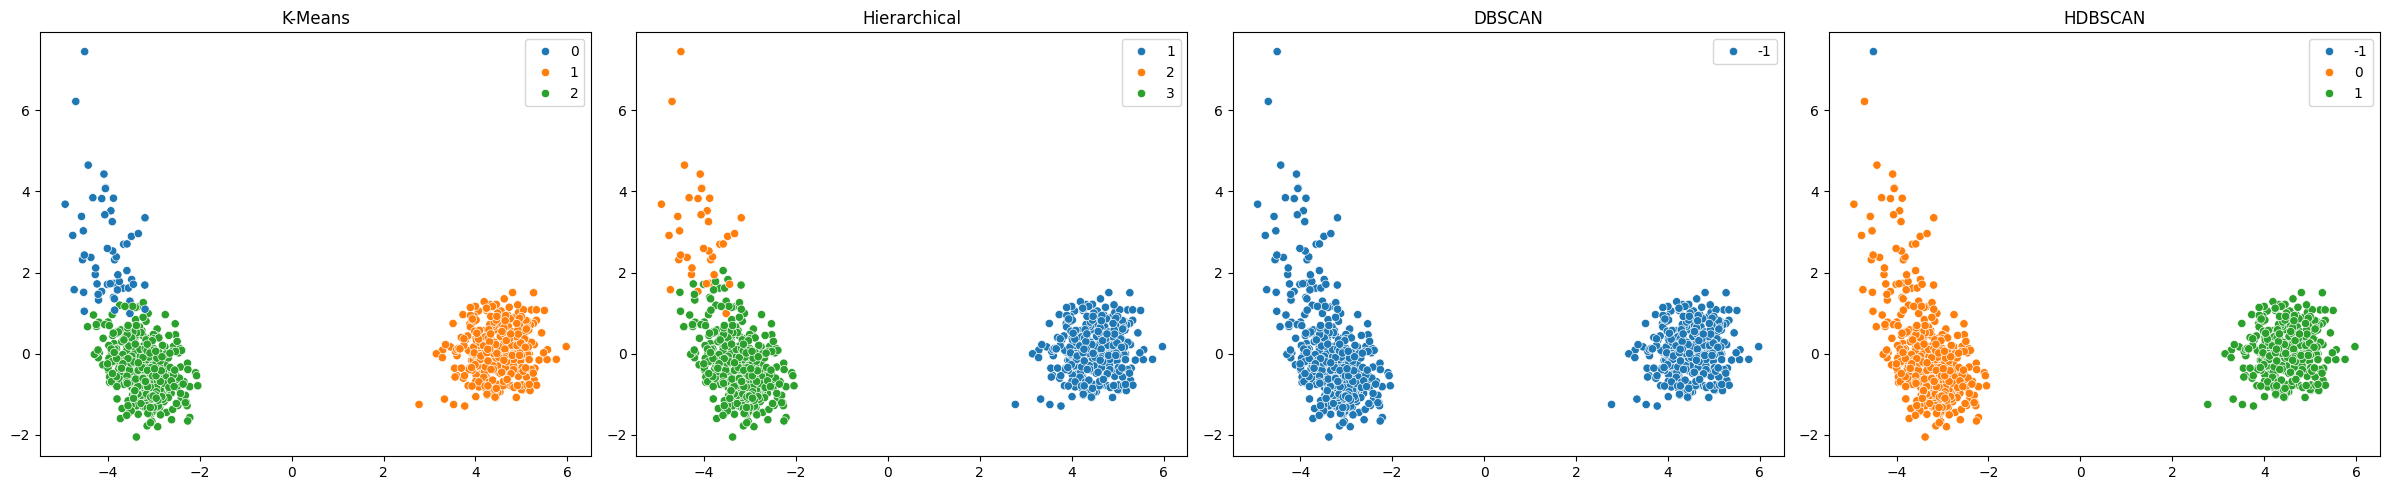

hdbscan_cluster  -1    0    1
bot_label                    
0                 1  460    0
1                 0    0  339


In [9]:
# =========================
# FEATURE-BASED CLUSTERING
# =========================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster

import hdbscan

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1. Load dataset
# -------------------------
csv_path = "Twitter-Bot-Detection-Dataset/synthetic_bot_detection_dataset.csv"
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
display(df.head())

# -------------------------
# 2. Identify label column (if present)
# -------------------------
label_column = None
for col in df.columns:
    if col.lower() in ["label", "bot_label", "Bot Label", "is_bot", "class"]:
        label_column = col
        break

print("Label column:", label_column)

# -------------------------
# 3. Select numerical features
# -------------------------
X = df.select_dtypes(include=[np.number]).copy()

if label_column and label_column in X.columns:
    X.drop(columns=[label_column], inplace=True)

X = X.fillna(0)

print("Number of features used:", X.shape[1])

# -------------------------
# 4. Scale features
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 5. PCA for visualization
# -------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance (PCA):", pca.explained_variance_ratio_)

# -------------------------
# 6. K-Means clustering
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means silhouette score:",
      silhouette_score(X_scaled, kmeans_labels))

# -------------------------
# 7. Hierarchical clustering
# -------------------------
Z = linkage(X_scaled, method="ward")
hier_labels = fcluster(Z, t=3, criterion="maxclust")

print("Hierarchical silhouette score:",
      silhouette_score(X_scaled, hier_labels))

# -------------------------
# 8. DBSCAN clustering
# -------------------------
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print("DBSCAN clusters detected:", dbscan_clusters)

# -------------------------
# 9. HDBSCAN clustering (NEW)
# -------------------------
hdbscan_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric="euclidean"
)

hdbscan_labels = hdbscan_clusterer.fit_predict(X_scaled)

hdbscan_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
noise_ratio = np.mean(hdbscan_labels == -1)

print("HDBSCAN clusters detected:", hdbscan_clusters)
print("HDBSCAN noise ratio:", round(noise_ratio, 3))

# -------------------------
# 10. Visualization
# -------------------------
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=kmeans_labels, palette="tab10", ax=axes[0]
)
axes[0].set_title("K-Means")

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=hier_labels, palette="tab10", ax=axes[1]
)
axes[1].set_title("Hierarchical")

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=dbscan_labels, palette="tab10", ax=axes[2]
)
axes[2].set_title("DBSCAN")

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=hdbscan_labels, palette="tab10", ax=axes[3]
)
axes[3].set_title("HDBSCAN")

plt.tight_layout()
plt.show()

# -------------------------
# 11. Optional: compare with labels
# -------------------------
if label_column:
    df["hdbscan_cluster"] = hdbscan_labels
    print(pd.crosstab(df[label_column], df["hdbscan_cluster"]))

### t-SNE embedding

In [13]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

Dataset shape: (800, 23)


,account_age_days,profile_completeness,default_avatar,followers_count,friends_count,follower_following_ratio,followers_growth_rate,posts_per_day,burstiness,night_activity_ratio,...,message_length,lexical_diversity,sentiment_polarity,emoji_frequency,hashtag_count,url_present,topic_id,narrative_consistency_score,message_content,bot_label
0,1330,0.933907,0,960,320,2.990654,0.011937,2.506247,0.139990,0.237775,...,53,0.522565,0.333199,0.284638,1,0,6,0.596885,I will vote in the Lithuanian elections this w...,0
1,240,0.309225,1,26,452,0.057395,0.057230,43.991658,0.714000,0.989502,...,54,0.276492,-0.311738,0.023338,7,1,0,0.835150,Lithuania elections are manipulated by foreign...,1
2,2261,0.942519,0,700,365,1.912568,0.006092,0.939525,0.373693,0.232046,...,48,0.863728,0.055268,0.215631,1,0,4,0.408027,Reading news about Lithuania election campaigns.,0
3,2649,0.932540,0,1600,752,2.124834,0.018790,4.526723,0.339160,0.376562,...,51,0.630132,0.133206,0.117837,0,0,6,0.342701,Elections in Lithuania are important for democ...,0
4,3312,0.788882,0,479,542,0.882136,0.003305,0.570364,0.269361,0.218464,...,51,0.784537,0.374105,0.201490,1,0,5,0.460431,Elections in Lithuania are important for democ...,0


Label column: bot_label
Number of features used: 21
Explained variance (PCA): [0.71623798 0.04757024 0.04362036]
K-Means silhouette score: 0.41615246300267655
Hierarchical silhouette score: 0.44557945862143894
DBSCAN clusters detected: 0
HDBSCAN clusters detected: 2
HDBSCAN noise ratio: 0.001


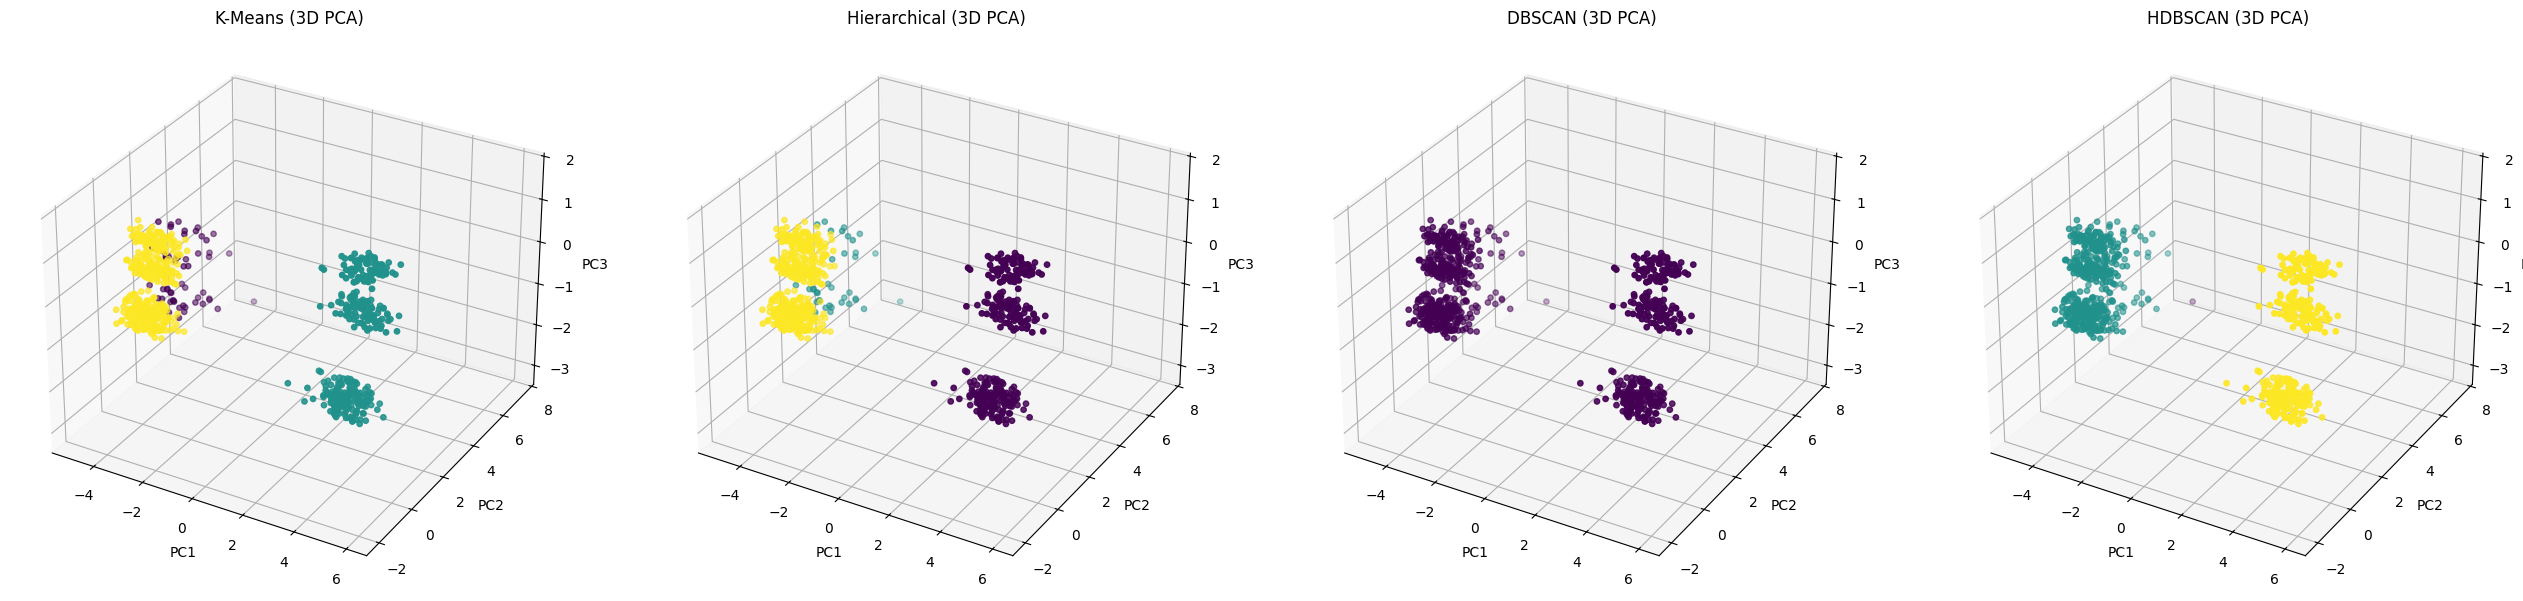

hdbscan_cluster  -1    0    1
bot_label                    
0                 1  460    0
1                 0    0  339


In [11]:
# =========================
# FEATURE-BASED CLUSTERING
# =========================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster

import hdbscan

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

# -------------------------
# 1. Load dataset
# -------------------------
csv_path = "Twitter-Bot-Detection-Dataset/synthetic_bot_detection_dataset.csv"
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
display(df.head())

# -------------------------
# 2. Identify label column (if present)
# -------------------------
label_column = None
for col in df.columns:
    if col.lower() in ["label", "bot_label", "bot label", "is_bot", "class"]:
        label_column = col
        break

print("Label column:", label_column)

# -------------------------
# 3. Select numerical features
# -------------------------
X = df.select_dtypes(include=[np.number]).copy()

if label_column and label_column in X.columns:
    X.drop(columns=[label_column], inplace=True)

X = X.fillna(0)

print("Number of features used:", X.shape[1])

# -------------------------
# 4. Scale features
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 5. PCA for 3D visualization
# -------------------------
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance (PCA):", pca.explained_variance_ratio_)

# -------------------------
# 6. K-Means clustering
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means silhouette score:",
      silhouette_score(X_scaled, kmeans_labels))

# -------------------------
# 7. Hierarchical clustering
# -------------------------
Z = linkage(X_scaled, method="ward")
hier_labels = fcluster(Z, t=3, criterion="maxclust")

print("Hierarchical silhouette score:",
      silhouette_score(X_scaled, hier_labels))

# -------------------------
# 8. DBSCAN clustering
# -------------------------
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print("DBSCAN clusters detected:", dbscan_clusters)

# -------------------------
# 9. HDBSCAN clustering
# -------------------------
hdbscan_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric="euclidean"
)

hdbscan_labels = hdbscan_clusterer.fit_predict(X_scaled)

hdbscan_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
noise_ratio = np.mean(hdbscan_labels == -1)

print("HDBSCAN clusters detected:", hdbscan_clusters)
print("HDBSCAN noise ratio:", round(noise_ratio, 3))

# -------------------------
# 10. 3D Visualization
# -------------------------
fig = plt.figure(figsize=(26, 6))

# --- K-Means ---
ax1 = fig.add_subplot(141, projection="3d")
ax1.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c=kmeans_labels, s=15
)
ax1.set_title("K-Means (3D PCA)")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_zlabel("PC3")

# --- Hierarchical ---
ax2 = fig.add_subplot(142, projection="3d")
ax2.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c=hier_labels, s=15
)
ax2.set_title("Hierarchical (3D PCA)")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")

# --- DBSCAN ---
ax3 = fig.add_subplot(143, projection="3d")
ax3.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c=dbscan_labels, s=15
)
ax3.set_title("DBSCAN (3D PCA)")
ax3.set_xlabel("PC1")
ax3.set_ylabel("PC2")
ax3.set_zlabel("PC3")

# --- HDBSCAN ---
ax4 = fig.add_subplot(144, projection="3d")
ax4.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c=hdbscan_labels, s=15
)
ax4.set_title("HDBSCAN (3D PCA)")
ax4.set_xlabel("PC1")
ax4.set_ylabel("PC2")
ax4.set_zlabel("PC3")

plt.tight_layout()
plt.show()

# -------------------------
# 11. Optional: compare with labels
# -------------------------
if label_column:
    df["hdbscan_cluster"] = hdbscan_labels
    print(pd.crosstab(df[label_column], df["hdbscan_cluster"]))

### PCA -> UMAP

Dataset shape: (800, 23)


,account_age_days,profile_completeness,default_avatar,followers_count,friends_count,follower_following_ratio,followers_growth_rate,posts_per_day,burstiness,night_activity_ratio,...,message_length,lexical_diversity,sentiment_polarity,emoji_frequency,hashtag_count,url_present,topic_id,narrative_consistency_score,message_content,bot_label
0,1330,0.933907,0,960,320,2.990654,0.011937,2.506247,0.139990,0.237775,...,53,0.522565,0.333199,0.284638,1,0,6,0.596885,I will vote in the Lithuanian elections this w...,0
1,240,0.309225,1,26,452,0.057395,0.057230,43.991658,0.714000,0.989502,...,54,0.276492,-0.311738,0.023338,7,1,0,0.835150,Lithuania elections are manipulated by foreign...,1
2,2261,0.942519,0,700,365,1.912568,0.006092,0.939525,0.373693,0.232046,...,48,0.863728,0.055268,0.215631,1,0,4,0.408027,Reading news about Lithuania election campaigns.,0
3,2649,0.932540,0,1600,752,2.124834,0.018790,4.526723,0.339160,0.376562,...,51,0.630132,0.133206,0.117837,0,0,6,0.342701,Elections in Lithuania are important for democ...,0
4,3312,0.788882,0,479,542,0.882136,0.003305,0.570364,0.269361,0.218464,...,51,0.784537,0.374105,0.201490,1,0,5,0.460431,Elections in Lithuania are important for democ...,0


Label column: bot_label
Number of features used: 21
UMAP embedding shape: (800, 3)
K-Means silhouette score: 0.41615246300267655
Hierarchical silhouette score: 0.44557945862143894
DBSCAN clusters detected: 0
HDBSCAN clusters detected: 2
HDBSCAN noise ratio: 0.001


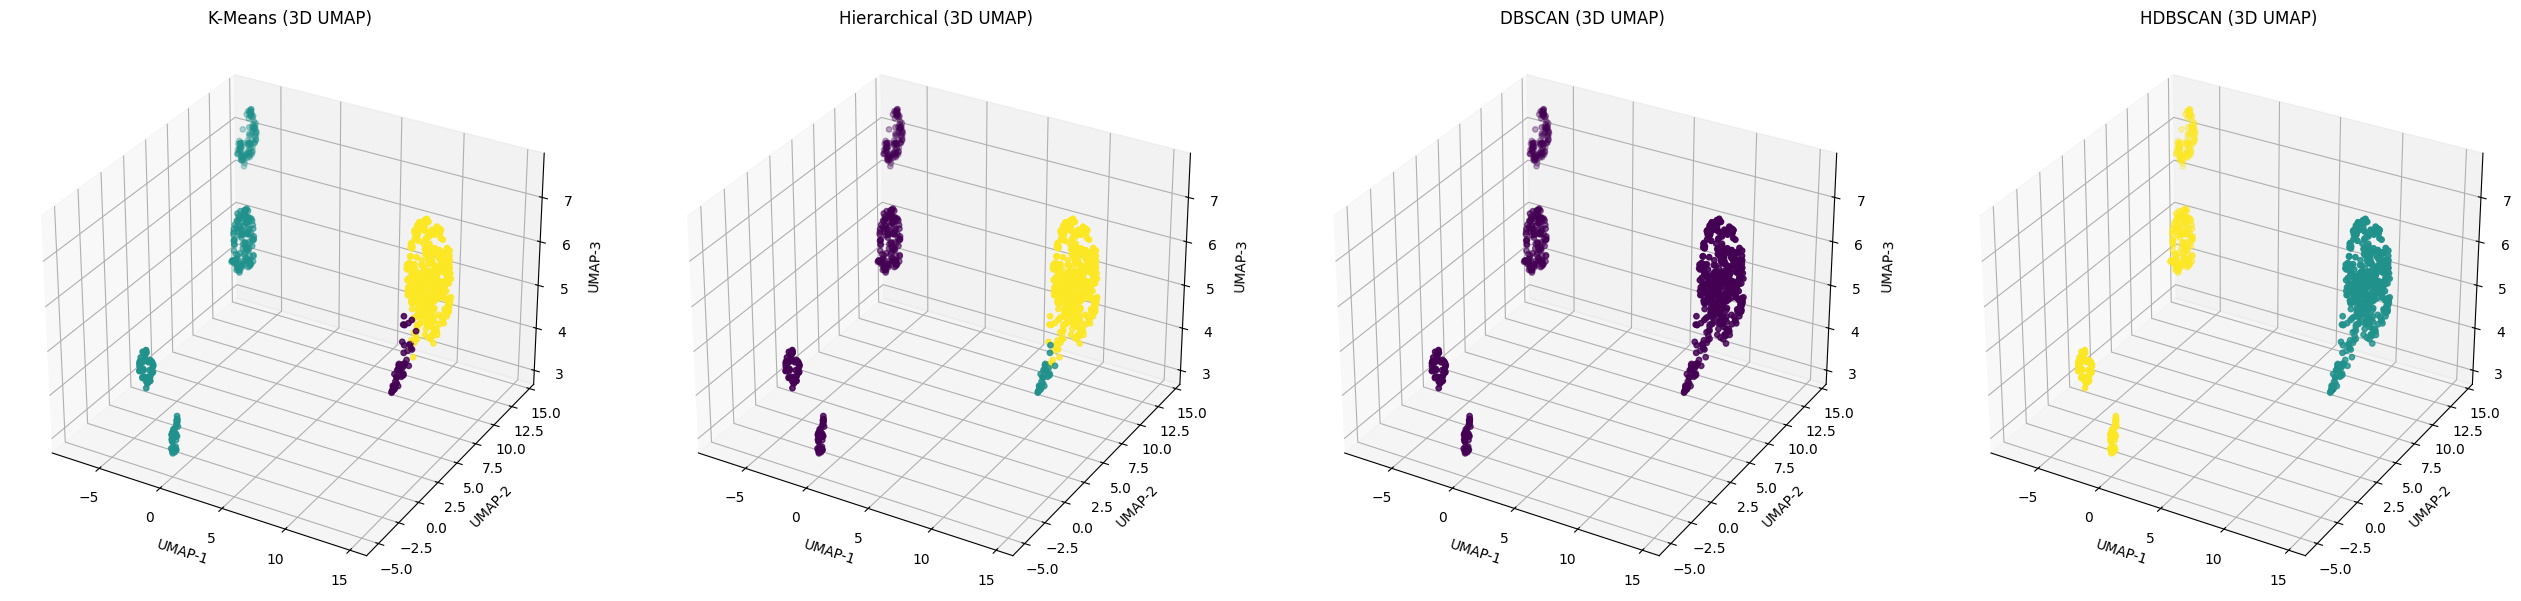

hdbscan_cluster  -1    0    1
bot_label                    
0                 1  460    0
1                 0    0  339


In [12]:
# =========================
# FEATURE-BASED CLUSTERING
# WITH UMAP (3D)
# =========================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster

import hdbscan
import umap

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

# -------------------------
# 1. Load dataset
# -------------------------
csv_path = "Twitter-Bot-Detection-Dataset/synthetic_bot_detection_dataset.csv"
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
display(df.head())

# -------------------------
# 2. Identify label column (if present)
# -------------------------
label_column = None
for col in df.columns:
    if col.lower() in ["label", "bot_label", "bot label", "is_bot", "class"]:
        label_column = col
        break

print("Label column:", label_column)

# -------------------------
# 3. Select numerical features
# -------------------------
X = df.select_dtypes(include=[np.number]).copy()

if label_column and label_column in X.columns:
    X.drop(columns=[label_column], inplace=True)

X = X.fillna(0)

print("Number of features used:", X.shape[1])

# -------------------------
# 4. Scale features
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 5. UMAP for 3D visualization
# -------------------------
umap_3d = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap = umap_3d.fit_transform(X_scaled)

print("UMAP embedding shape:", X_umap.shape)

# -------------------------
# 6. K-Means clustering
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means silhouette score:",
      silhouette_score(X_scaled, kmeans_labels))

# -------------------------
# 7. Hierarchical clustering
# -------------------------
Z = linkage(X_scaled, method="ward")
hier_labels = fcluster(Z, t=3, criterion="maxclust")

print("Hierarchical silhouette score:",
      silhouette_score(X_scaled, hier_labels))

# -------------------------
# 8. DBSCAN clustering
# -------------------------
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print("DBSCAN clusters detected:", dbscan_clusters)

# -------------------------
# 9. HDBSCAN clustering
# -------------------------
hdbscan_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric="euclidean"
)

hdbscan_labels = hdbscan_clusterer.fit_predict(X_scaled)

hdbscan_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
noise_ratio = np.mean(hdbscan_labels == -1)

print("HDBSCAN clusters detected:", hdbscan_clusters)
print("HDBSCAN noise ratio:", round(noise_ratio, 3))

# -------------------------
# 10. 3D Visualization (UMAP)
# -------------------------
fig = plt.figure(figsize=(26, 6))

# --- K-Means ---
ax1 = fig.add_subplot(141, projection="3d")
ax1.scatter(
    X_umap[:, 0], X_umap[:, 1], X_umap[:, 2],
    c=kmeans_labels, s=15
)
ax1.set_title("K-Means (3D UMAP)")
ax1.set_xlabel("UMAP-1")
ax1.set_ylabel("UMAP-2")
ax1.set_zlabel("UMAP-3")

# --- Hierarchical ---
ax2 = fig.add_subplot(142, projection="3d")
ax2.scatter(
    X_umap[:, 0], X_umap[:, 1], X_umap[:, 2],
    c=hier_labels, s=15
)
ax2.set_title("Hierarchical (3D UMAP)")
ax2.set_xlabel("UMAP-1")
ax2.set_ylabel("UMAP-2")
ax2.set_zlabel("UMAP-3")

# --- DBSCAN ---
ax3 = fig.add_subplot(143, projection="3d")
ax3.scatter(
    X_umap[:, 0], X_umap[:, 1], X_umap[:, 2],
    c=dbscan_labels, s=15
)
ax3.set_title("DBSCAN (3D UMAP)")
ax3.set_xlabel("UMAP-1")
ax3.set_ylabel("UMAP-2")
ax3.set_zlabel("UMAP-3")

# --- HDBSCAN ---
ax4 = fig.add_subplot(144, projection="3d")
ax4.scatter(
    X_umap[:, 0], X_umap[:, 1], X_umap[:, 2],
    c=hdbscan_labels, s=15
)
ax4.set_title("HDBSCAN (3D UMAP)")
ax4.set_xlabel("UMAP-1")
ax4.set_ylabel("UMAP-2")
ax4.set_zlabel("UMAP-3")

plt.tight_layout()
plt.show()

# -------------------------
# 11. Optional: compare with labels
# -------------------------
if label_column:
    df["hdbscan_cluster"] = hdbscan_labels
    print(pd.crosstab(df[label_column], df["hdbscan_cluster"]))

### Narrative Clustering with BERTopic (Text-Based)

In [7]:
# =========================
# NARRATIVE CLUSTERING USING BERTOPIC
# =========================

import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# -------------------------
# 1. Load dataset
# -------------------------
csv_path = "Twitter-Bot-Detection-Dataset/bot_detection_data.csv"
df = pd.read_csv(csv_path)

# -------------------------
# 2. Select text column
# -------------------------
# Adjust column name if needed
text_column_candidates = ["text", "Tweet", "content", "message"]

text_column = None
for col in text_column_candidates:
    if col in df.columns:
        text_column = col
        break

if text_column is None:
    raise ValueError("No text column found for narrative clustering")

documents = df[text_column].astype(str).tolist()

print("Using text column:", text_column)
print("Number of documents:", len(documents))

# -------------------------
# 3. Load embedding model
# -------------------------
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# -------------------------
# 4. Fit BERTopic model
# -------------------------
topic_model = BERTopic(
    embedding_model=embedding_model,
    language="multilingual",
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(documents)

df["topic"] = topics

# -------------------------
# 5. Inspect topics
# -------------------------
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))

# -------------------------
# 6. View top words per topic
# -------------------------
for topic_id in topic_info["Topic"].head(5):
    print(f"\nTopic {topic_id}")
    print(topic_model.get_topic(topic_id))

# -------------------------
# 7. Example: documents per narrative
# -------------------------
df.groupby("topic").size().sort_values(ascending=False).head(10)


Using text column: Tweet
Number of documents: 50000


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

2026-01-20 11:23:44,359 - BERTopic - Embedding - Completed ✓
2026-01-20 11:23:44,359 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-20 11:24:24,572 - BERTopic - Dimensionality - Completed ✓
2026-01-20 11:24:24,573 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-20 11:26:53,169 - BERTopic - Cluster - Completed ✓
2026-01-20 11:26:53,179 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-20 11:26:53,719 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,18745,-1_artist_girl_her_parent,"[artist, girl, her, parent, politics, son, she...",[Success method level would recognize defense ...
1,0,1103,0_hospital_medical_doctor_health,"[hospital, medical, doctor, health, treatment,...",[Find within wife his tell before hospital ope...
2,1,941,1_teacher_college_student_education,"[teacher, college, student, education, profess...","[Respond yes them arm student teacher set., Ta..."
3,2,797,2_dog_animal_total_explain,"[dog, animal, total, explain, argue, amount, y...",[Participant significant decision dog represen...
4,3,790,3_attorney_lawyer_court_law,"[attorney, lawyer, court, law, condition, case...",[Sense different lawyer certain return shake t...
5,4,757,4_marriage_husband_wife_couple,"[marriage, husband, wife, couple, outside, rel...",[Find night series point wife consumer agent m...
6,5,728,5_church_religious_if_great,"[church, religious, if, great, morning, such, ...","[Although attack face station church involve.,..."
7,6,687,6_soldier_military_war_after,"[soldier, military, war, after, end, former, a...",[Sister yes health soldier military pass manag...
8,7,658,7_color_blue_red_former,"[color, blue, red, former, white, yourself, my...",[Name moment follow management total red bill ...
9,8,617,8_democrat_republican_democratic_party,"[democrat, republican, democratic, party, dete...",[Year Democrat Republican these explain someth...



Topic -1
[('artist', np.float64(0.0028584659530299177)), ('girl', np.float64(0.0026790168997622107)), ('her', np.float64(0.0026513283889941434)), ('parent', np.float64(0.002630856352376576)), ('politics', np.float64(0.0026080223641713703)), ('son', np.float64(0.0025991023001045357)), ('she', np.float64(0.002594090176191481)), ('art', np.float64(0.002529661447572844)), ('woman', np.float64(0.0025242521045206246)), ('political', np.float64(0.00252340358401316))]

Topic 0
[('hospital', np.float64(0.045594640130879605)), ('medical', np.float64(0.038047946015279464)), ('doctor', np.float64(0.03557998137690973)), ('health', np.float64(0.021422818227216752)), ('treatment', np.float64(0.018452898349134057)), ('care', np.float64(0.011269571736480253)), ('order', np.float64(0.0035293017035560093)), ('into', np.float64(0.0031961211199311116)), ('good', np.float64(0.0031272085496631373)), ('box', np.float64(0.0031164167307760845))]

Topic 1
[('teacher', np.float64(0.04673824515161175)), ('college

topic
-1    18745
 0     1103
 1      941
 2      797
 3      790
 4      757
 5      728
 6      687
 7      658
 8      617
dtype: int64